# Perceptron

simplest neural network: inputs → weighted sum → step function.

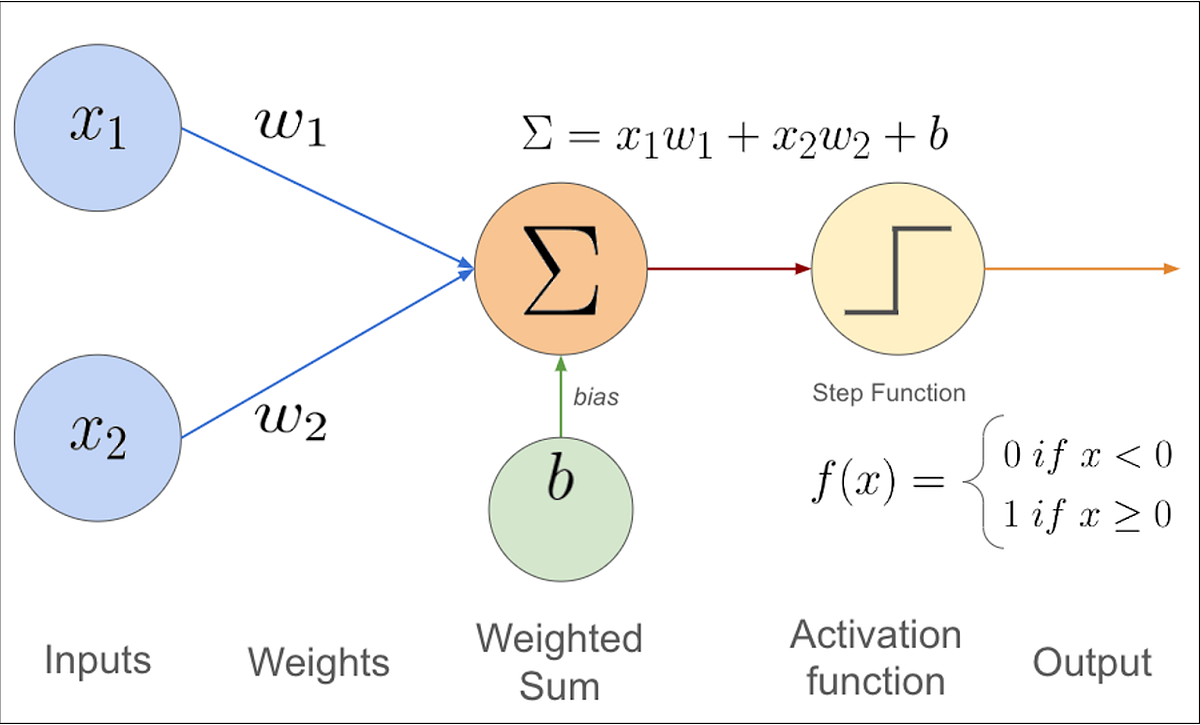

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DATA: AND gate
# ---------------------------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    0,
    0,

    0,
    1
])


# ---------------------------------------------------------
# PERCEPTRON
# ---------------------------------------------------------

class Perceptron:

    def __init__(self, input_size, learning_rate=0.1):

        self.weights = np.zeros(input_size)
        self.bias = 0

        self.lr = learning_rate


    def step(self, x):

        return 1 if x >= 0 else 0


    def predict(self, X):

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            predictions.append(
                self.step(z)
            )

        return np.array(predictions)


    def train(self, X, y, epochs=20):

        for epoch in range(epochs):

            errors = 0

            for x, target in zip(X, y):

                prediction = self.predict(
                    x.reshape(1, -1)
                )[0]

                error = target - prediction

                # Weight update
                self.weights += self.lr * error * x

                # Bias update
                self.bias += self.lr * error

                if error != 0:

                    errors += 1

            print(
                f"Epoch {epoch+1:2d} | Errors: {errors}"
            )

            if errors == 0:
                break


# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------

model = Perceptron(2)

model.train(X, y)

print("\nPredictions:")

print(model.weights, " - ", model.bias)

print(model.predict(X))

Epoch  1 | Errors: 2
Epoch  2 | Errors: 3
Epoch  3 | Errors: 3
Epoch  4 | Errors: 0

Predictions:
[0.2 0.1]  -  -0.20000000000000004
[0 0 0 1]


# Single Neuron

Now replace the hard step function with sigmoid and use gradient descent.

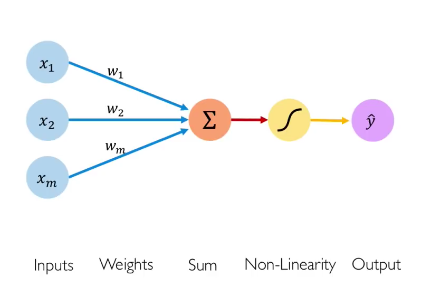

In [3]:
import numpy as np


# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=float)


# ---------------------------------------------------------
# SIGMOID
# ---------------------------------------------------------

def sigmoid(x):

    return 1 / (1 + np.exp(-x))


# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------

weights = np.random.randn(2, 1)

bias = np.zeros((1, 1))

learning_rate = 0.5


# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------

for epoch in range(5000):

    # Forward

    z = X @ weights + bias

    prediction = sigmoid(z)


    # Binary Cross Entropy

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(prediction + epsilon)
        +
        (1-y) * np.log(1-prediction + epsilon)
    )


    # Backpropagation

    dz = prediction - y

    dw = X.T @ dz / len(X)

    db = np.mean(dz, axis=0, keepdims=True)


    # Update

    weights -= learning_rate * dw

    bias -= learning_rate * db


    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch} | Loss: {loss:.4f}"
        )


# ---------------------------------------------------------
# RESULT
# ---------------------------------------------------------

prediction = sigmoid(
    X @ weights + bias
)

print("\nProbabilities:")

print(prediction)

print("\nClasses:")

print((prediction >= 0.5).astype(int))

Epoch 0 | Loss: 0.7739
Epoch 1000 | Loss: 0.0344
Epoch 2000 | Loss: 0.0174
Epoch 3000 | Loss: 0.0116
Epoch 4000 | Loss: 0.0087

Probabilities:
[[7.64192294e-07]
 [8.09721471e-03]
 [8.09721479e-03]
 [9.88662483e-01]]

Classes:
[[0]
 [0]
 [0]
 [1]]


# One Hidden-Layer ANN

Input

  │

  ▼

Hidden Layer

  │

  ▼

Output Layer

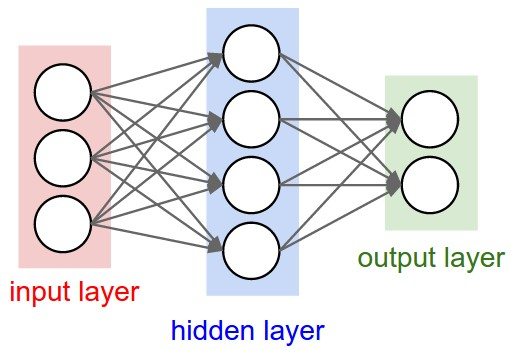

In [ ]:
import numpy as np


# We'll use XOR because a single neuron/perceptron cannot solve XOR.

# =========================================================
# XOR DATA
# =========================================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)


# =========================================================
# ACTIVATION FUNCTIONS
# =========================================================

def sigmoid(x):

    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):

    s = sigmoid(x)

    return s * (1 - s)


# =========================================================
# NETWORK
# =========================================================

input_size = 2

hidden_size = 4

output_size = 1


np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size)

b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)

b2 = np.zeros((1, output_size))


learning_rate = 1.0


# =========================================================
# TRAIN
# =========================================================

for epoch in range(10000):

    # -----------------------------------------------------
    # FORWARD PASS
    # -----------------------------------------------------

    Z1 = X @ W1 + b1

    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2

    A2 = sigmoid(Z2)


    # -----------------------------------------------------
    # LOSS
    # -----------------------------------------------------

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(A2 + epsilon)
        +
        (1-y) * np.log(1-A2 + epsilon)
    )


    # -----------------------------------------------------
    # BACKPROP
    # -----------------------------------------------------

    # DL/DZ2
    dZ2 = A2 - y

    
    dW2 = np.mean(A1.T @ dZ2)

    db2 = np.mean(dZ2, axis=0, keepdims=True)


    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * sigmoid_derivative(Z1)

    dW1 = X.T @ dZ1 / len(X)

    db1 = np.mean(dZ1, axis=0, keepdims=True)


    # -----------------------------------------------------
    # UPDATE
    # -----------------------------------------------------

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1


    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch} | Loss: {loss:.6f}"
        )


# =========================================================
# TEST
# =========================================================

output = sigmoid(
    sigmoid(X @ W1 + b1) @ W2 + b2
)

print("\nPredictions:")

print(output)

print("\nClasses:")

print((output >= 0.5).astype(int))

Epoch 0 | Loss: 0.762777
Epoch 1000 | Loss: 0.014722
Epoch 2000 | Loss: 0.004025
Epoch 3000 | Loss: 0.002178
Epoch 4000 | Loss: 0.001466
Epoch 5000 | Loss: 0.001097
Epoch 6000 | Loss: 0.000873
Epoch 7000 | Loss: 0.000723
Epoch 8000 | Loss: 0.000616
Epoch 9000 | Loss: 0.000536

Predictions:
[[2.29610155e-04]
 [9.99607397e-01]
 [9.99421026e-01]
 [6.96705159e-04]]

Classes:
[[0]
 [1]
 [1]
 [0]]
